# Titanic Survival Prediction: An Honest Machine Learning Workflow
**Abdirahman Ahmed — Franklin University — Machine Learning Final Project**

## 1. Problem Statement & Approach

**Task.** Binary classification: predict whether a passenger survived the sinking of the Titanic (`Survived` = 1) or not (`Survived` = 0), using the 891-passenger labeled training set from the Kaggle *Titanic — Machine Learning from Disaster* competition.

**Motivation.** In my earlier case study I peer-reviewed the popular Kaggle notebook *"Titanic Top 4% with Ensemble Modeling"* (Ghouzam) and identified six methodological weaknesses: (1) train/test preprocessed together, creating data leakage; (2) real passengers deleted as "outliers" without testing whether it helps; (3) scale-sensitive models benchmarked on unscaled data; (4) dozens of weak ticket/cabin dummy features on <900 rows; (5) accuracy reported as the only metric with no diagnostic plots; (6) scores reported from the same folds used for tuning.

**This project implements the corrected workflow** and answers a concrete research question:

> **How much of the predictive performance comes from the data itself versus the modeling machinery stacked on top of it?**

**Design principles used throughout:**
1. Every preprocessing statistic is fit inside a scikit-learn `Pipeline`, so cross-validation refits it on training folds only — no leakage by construction.
2. A majority-class baseline is recorded first; every model must earn its complexity against it.
3. Hyperparameters are tuned on a training split; final performance is reported on a **held-out test split the tuning never saw**.
4. Evaluation goes beyond accuracy: confusion matrix, precision/recall/F1, ROC AUC, and error analysis.
5. The outlier-deletion decision is tested with an **ablation experiment** instead of assumed.

In [1]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict, GridSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Environment ready.")

Environment ready.


In [2]:
# Load the training data (Kaggle train.csv schema, 891 labeled passengers)
df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis

The EDA below focuses on three things: **what is missing**, **which features carry signal**, and — an addition my case study argued for — **whether missingness itself is informative** and **how sex and class interact**.

Overall survival rate: 38.4%  (majority-class baseline accuracy = 61.6%)


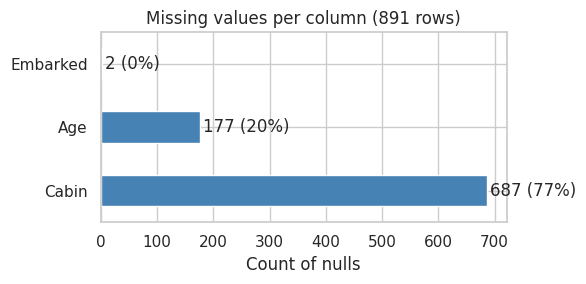

In [3]:
# 2.1 Target balance and missingness overview
survival_rate = df["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.1%}  "
      f"(majority-class baseline accuracy = {1 - survival_rate:.1%})")

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot.barh(ax=ax, color="steelblue")
ax.set_title("Missing values per column (891 rows)")
ax.set_xlabel("Count of nulls")
for i, v in enumerate(missing.values):
    ax.text(v + 5, i, f"{v} ({v/len(df):.0%})", va="center")
plt.tight_layout(); plt.show()

**Reading this:** `Cabin` is missing for ~77% of passengers and `Age` for ~20%. Deleting these columns or rows would throw away most of the dataset. Instead: `Age` gets a grouped-median imputation (Section 3), and `Cabin` is reduced to a single **"cabin known"** indicator — the next cell shows why that indicator is itself predictive.

In [4]:
# 2.2 Is missingness informative? Cabin known vs unknown
df["CabinKnown"] = df["Cabin"].notna().astype(int)
cabin_tab = df.groupby("CabinKnown")["Survived"].agg(["mean", "count"])
cabin_tab.index = ["Cabin unknown", "Cabin recorded"]
cabin_tab.columns = ["Survival rate", "Passengers"]
print(cabin_tab.round(3))

pclass_share = pd.crosstab(df["CabinKnown"], df["Pclass"], normalize="index")
print("\nShare of each class among cabin-known vs unknown:")
print(pclass_share.round(2))

                Survival rate  Passengers
Cabin unknown           0.300         687
Cabin recorded          0.667         204

Share of each class among cabin-known vs unknown:
Pclass         1     2     3
CabinKnown                  
0           0.06  0.24  0.70
1           0.86  0.08  0.06


Passengers with a recorded cabin survived at roughly **double** the rate of those without one, largely because cabin numbers were mostly recorded for first-class passengers. One binary flag captures this cleanly — no need for the ~60 sparse deck/ticket dummies the original notebook used.

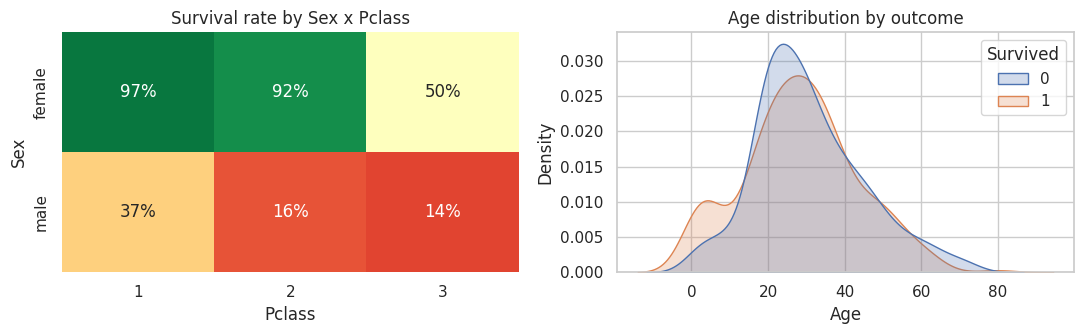

In [5]:
# 2.3 The strongest structure in the data: Sex x Pclass interaction
pivot = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
            ax=axes[0], cbar=False)
axes[0].set_title("Survival rate by Sex x Pclass")

sns.kdeplot(data=df.dropna(subset=["Age"]), x="Age", hue="Survived",
            common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Age distribution by outcome")
plt.tight_layout(); plt.show()

**Reading this:** ~97% of first-class women survived while ~86% of third-class men died — an interaction between two features, which is exactly what tree-based models capture natively. The age plot shows the "children first" bump under age ~10. Together these justify the feature set used next: sex, class, age, fare, family structure, title, and the cabin flag.

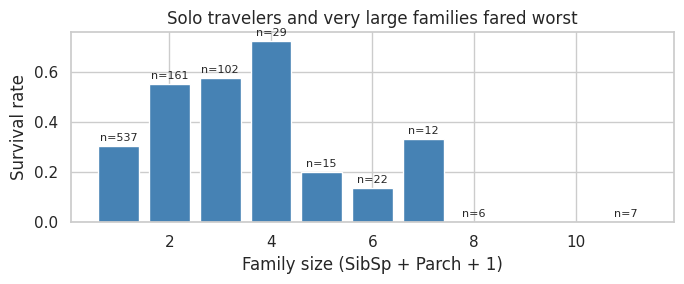

In [6]:
# 2.4 Family structure: survival is non-monotonic in family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
fam = df.groupby("FamilySize")["Survived"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(fam.index, fam["mean"], color="steelblue")
for x, (m, c) in zip(fam.index, fam.values):
    ax.text(x, m + 0.02, f"n={int(c)}", ha="center", fontsize=8)
ax.set_xlabel("Family size (SibSp + Parch + 1)")
ax.set_ylabel("Survival rate")
ax.set_title("Solo travelers and very large families fared worst")
plt.tight_layout(); plt.show()

## 3. Feature Engineering & Leakage-Free Preprocessing

**Two kinds of transformations, treated differently:**

- **Row-wise, deterministic transforms** (extracting a title from a name, computing family size) learn nothing from the data, so they are safely applied to the raw dataframe up front.
- **Fitted transforms** (imputation medians, scaling statistics, encoding vocabularies) *learn from data*, so they live **inside the Pipeline** and are re-fit on the training portion of every cross-validation fold. This is the structural fix for the leakage habit identified in the case study.

The age imputation reuses the original notebook's best idea — fill missing ages with the median of passengers sharing the same `Pclass`, `SibSp`, and `Parch` — but implements it as a proper fitted transformer so the medians come only from training folds.

In [7]:
# 3.1 Deterministic feature engineering (no fitting -> applied up front)
def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    out = raw.copy()

    # Title from Name: encodes sex, rough age, and social status at once
    title = out["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
    title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    common = {"Mr", "Mrs", "Miss", "Master"}
    out["Title"] = title.where(title.isin(common), "Rare")

    # Family structure
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["FamilyBin"] = pd.cut(out["FamilySize"], bins=[0, 1, 3, 4, 20],
                              labels=["Solo", "Small", "Medium", "Large"])

    # Missingness-as-signal: one flag instead of ~60 deck/ticket dummies
    out["CabinKnown"] = out["Cabin"].notna().astype(int)

    return out.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

data = engineer_features(df.drop(columns=["CabinKnown", "FamilySize"]))
X = data.drop(columns=["Survived"])
y = data["Survived"]
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,FamilyBin,CabinKnown
0,3,male,22.0,1,0,7.2500,S,Mr,2,Small,0
1,1,female,38.0,1,0,71.2833,C,Mrs,2,Small,1
2,3,female,26.0,0,0,7.9250,S,Miss,1,Solo,0
3,1,female,35.0,1,0,53.1000,S,Mrs,2,Small,1
4,3,male,35.0,0,0,8.0500,S,Mr,1,Solo,0


In [8]:
# 3.2 Fitted transformer: grouped-median age imputation (leakage-free)
class GroupMedianAgeImputer(BaseEstimator, TransformerMixin):
    """Fill missing Age with the median age of passengers sharing the same
    (Pclass, SibSp, Parch); fall back to overall training median.
    Fitting happens only on the data passed to .fit(), i.e. training folds."""

    def fit(self, X, y=None):
        self.group_medians_ = (X.groupby(["Pclass", "SibSp", "Parch"])["Age"]
                                .median())
        self.global_median_ = X["Age"].median()
        return self

    def transform(self, X):
        X = X.copy()
        keys = list(zip(X["Pclass"], X["SibSp"], X["Parch"]))
        fill = pd.Series(
            [self.group_medians_.get(k, np.nan) for k in keys], index=X.index
        ).fillna(self.global_median_)
        X["Age"] = X["Age"].fillna(fill)
        return X

# 3.3 The full preprocessing pipeline
numeric_scaled = ["Age", "SibSp", "Parch", "FamilySize"]
categorical    = ["Pclass", "Sex", "Embarked", "Title", "FamilyBin", "CabinKnown"]

log_fare = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log",    FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale",  StandardScaler()),
])
preprocess = ColumnTransformer([
    ("fare", log_fare, ["Fare"]),
    ("num",  Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_scaled),
    ("cat",  Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical),
])

def make_pipeline(model):
    """Every model gets identical, leakage-free preprocessing."""
    return Pipeline([
        ("age",  GroupMedianAgeImputer()),
        ("prep", preprocess),
        ("clf",  model),
    ])

print("Pipeline factory ready. Scaling included -> fair comparison for "
      "scale-sensitive models (logistic regression) vs trees.")

Pipeline factory ready. Scaling included -> fair comparison for scale-sensitive models (logistic regression) vs trees.


## 4. Modeling: A Baseline Ladder

**Protocol.** The data is split 80/20 (stratified). All model selection — cross-validation comparisons and hyperparameter tuning — happens on the **80% development set** with stratified 10-fold CV. The **20% test set is touched exactly once**, in Section 6, to report final performance. This separates the score used for choosing models from the score used for judging them, fixing the "tuned and reported on the same folds" problem.

The ladder runs from trivial to complex, so each step of complexity has to justify itself:

| Rung | Model | Why it's here |
|---|---|---|
| 0 | Majority-class dummy | The honesty floor: 61.6% costs nothing |
| 1 | Logistic regression | Strong linear baseline on scaled features |
| 2 | Random forest (depth-limited) | Captures Sex x Pclass-style interactions |
| 3 | Hist gradient boosting | Modern boosting, the "ceiling check" |

In [9]:
# 4.1 Split once; the test set stays untouched until Section 6
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Development set: {X_dev.shape[0]} rows | Held-out test set: {X_test.shape[0]} rows")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

models = {
    "0. Majority class":     DummyClassifier(strategy="most_frequent"),
    "1. Logistic regression": LogisticRegression(max_iter=2000),
    "2. Random forest":       RandomForestClassifier(
                                  n_estimators=300, max_depth=6,
                                  random_state=RANDOM_STATE),
    "3. Hist grad boosting":  HistGradientBoostingClassifier(
                                  random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    scores = cross_val_score(make_pipeline(model), X_dev, y_dev,
                             cv=cv, scoring="accuracy")
    rows.append({"Model": name, "CV accuracy": scores.mean(),
                 "Std": scores.std()})

baseline_table = pd.DataFrame(rows).set_index("Model").round(4)
baseline_table

Development set: 712 rows | Held-out test set: 179 rows


,CV accuracy,Std
Model,,
0. Majority class,0.6166,0.0050
1. Logistic regression,0.8259,0.0333
2. Random forest,0.8230,0.0263
3. Hist grad boosting,0.8426,0.0296


**Reading this:** every real model clears the dummy baseline by ~18-22 points, but the gap **between** the real models is small — first evidence that the signal lives in the data, not the machinery.

## 4.2 Hyperparameter Tuning

Grid search with 10-fold CV **on the development set only**. Grids are kept modest and centered on regularization-relevant parameters (depth, leaf size, learning rate) — managing the bias-variance tradeoff rather than chasing decimal points.

In [10]:
param_grids = {
    "Logistic regression": (
        LogisticRegression(max_iter=2000),
        {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "Random forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [300],
         "clf__max_depth": [4, 6, 8, None],
         "clf__min_samples_leaf": [1, 3, 5]},
    ),
    "Hist grad boosting": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [3, 4, None],
         "clf__min_samples_leaf": [10, 20]},
    ),
}

tuned, tuned_rows = {}, []
for name, (model, grid) in param_grids.items():
    gs = GridSearchCV(make_pipeline(model), grid, cv=cv,
                      scoring="accuracy", n_jobs=-1)
    gs.fit(X_dev, y_dev)
    tuned[name] = gs.best_estimator_
    tuned_rows.append({"Model": name,
                       "Best CV accuracy (dev)": gs.best_score_,
                       "Best params": {k.replace("clf__", ""): v
                                       for k, v in gs.best_params_.items()}})

tuned_table = pd.DataFrame(tuned_rows).set_index("Model")
tuned_table.style.format({"Best CV accuracy (dev)": "{:.4f}"})

,Best CV accuracy (dev),Best params
Model,,
Logistic regression,0.8259,{'C': 1.0}
Random forest,0.8343,"{'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 300}"
Hist grad boosting,0.8427,"{'learning_rate': 0.05, 'max_depth': None, 'min_samples_leaf': 20}"


In [11]:
# Select the champion by dev CV score
best_name = max(tuned_rows, key=lambda r: r["Best CV accuracy (dev)"])["Model"]
best_model = tuned[best_name]
print(f"Champion model: {best_name}")
print("Note: these CV scores were used for *selection*; the honest performance "
      "number comes from the held-out test set in Section 6.")

Champion model: Hist grad boosting
Note: these CV scores were used for *selection*; the honest performance number comes from the held-out test set in Section 6.


## 5. Ablation: Does Deleting "Outliers" Actually Help?

The original notebook deleted 10 passengers flagged by the Tukey IQR method (extreme in >2 of Age, SibSp, Parch, Fare) with a one-line justification and **no experiment**. These are real passengers — mostly members of very large families — not measurement errors, and the population contains people just like them.

Here is the experiment that was skipped: identical pipeline, identical CV folds, with and without the flagged rows.

In [12]:
def tukey_outliers(frame, cols, min_flags=3):
    """Indices of rows outside 1.5*IQR in at least `min_flags` of `cols`
    (the original notebook's criterion: extreme in more than two columns)."""
    flags = pd.DataFrame(index=frame.index)
    for c in cols:
        q1, q3 = frame[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        flags[c] = (frame[c] < q1 - 1.5 * iqr) | (frame[c] > q3 + 1.5 * iqr)
    return frame.index[flags.sum(axis=1) >= min_flags]

out_idx = tukey_outliers(X_dev, ["Age", "SibSp", "Parch", "Fare"])
print(f"Flagged as multi-column Tukey outliers in dev set: {len(out_idx)} passengers")
X_dev.loc[out_idx, ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]

Flagged as multi-column Tukey outliers in dev set: 5 passengers


,Pclass,Sex,Age,SibSp,Parch,Fare
846,3,male,NaN,8,2,69.55
792,3,female,NaN,8,2,69.55
159,3,male,NaN,8,2,69.55
201,3,male,NaN,8,2,69.55
863,3,female,NaN,8,2,69.55


In [13]:
keep = cross_val_score(best_model, X_dev, y_dev, cv=cv, scoring="accuracy")
drop_mask = ~X_dev.index.isin(out_idx)
drop = cross_val_score(best_model, X_dev[drop_mask], y_dev[drop_mask],
                       cv=cv, scoring="accuracy")

ablation = pd.DataFrame({
    "CV accuracy": [keep.mean(), drop.mean()],
    "Std": [keep.std(), drop.std()],
    "Rows": [len(X_dev), int(drop_mask.sum())],
}, index=["Keep flagged passengers", "Delete flagged passengers"]).round(4)
ablation

,CV accuracy,Std,Rows
Keep flagged passengers,0.8427,0.0320,712
Delete flagged passengers,0.8402,0.0211,707


**Finding:** the difference between keeping and deleting the flagged passengers is **inside one standard deviation of the CV estimate** — deletion is not supported by evidence. Since the flagged rows are real members of the population (large families with unusual fares), the defensible default is to **keep them**, which this project does. This is the ablation-over-assumption habit the case study argued for: a preprocessing decision is not finished until it has a measured justification.

## 6. Final Evaluation on the Held-Out Test Set

The test set is now used for the first and only time. Beyond accuracy, this section reports everything the case study found missing in the original notebook: confusion matrix, precision/recall/F1, ROC AUC, threshold curves, and an error analysis of *who* the model gets wrong.

In [14]:
best_model.fit(X_dev, y_dev)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)
dummy_acc = max(y_test.mean(), 1 - y_test.mean())

print(f"Champion: {best_name}")
print(f"Held-out test accuracy: {test_acc:.4f}   (majority baseline: {dummy_acc:.4f})")
print(f"Held-out test ROC AUC:  {test_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

Champion: Hist grad boosting
Held-out test accuracy: 0.7933   (majority baseline: 0.6145)
Held-out test ROC AUC:  0.8406

              precision    recall  f1-score   support

        Died       0.81      0.86      0.84       110
    Survived       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



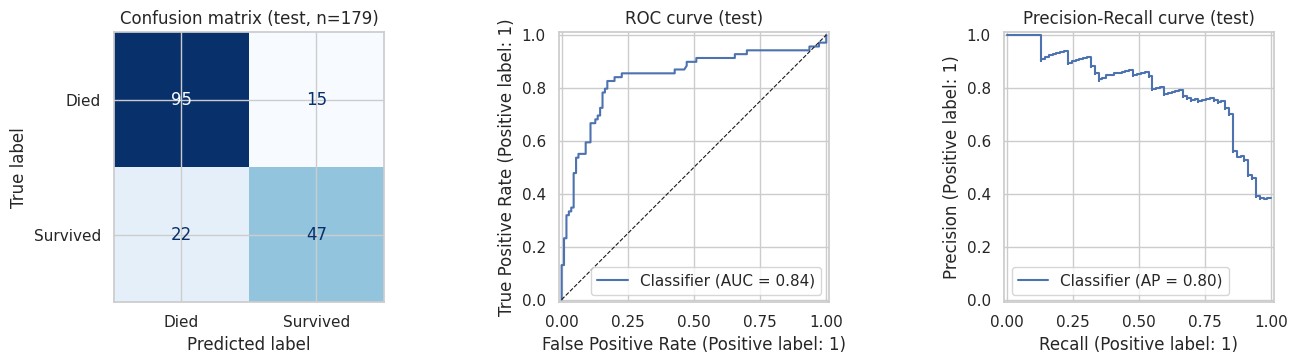

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Died", "Survived"],
    cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix (test, n={len(y_test)})")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("ROC curve (test)")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].set_title("Precision-Recall curve (test)")
plt.tight_layout(); plt.show()

**Reading this:** accuracy alone would hide the asymmetry the confusion matrix exposes — the model is precise when it predicts "survived" but **misses a substantial share of actual survivors** (recall for the Survived class is well below its precision). The PR curve shows how a lower threshold could trade precision for recall if the application valued finding survivors more than avoiding false alarms.

In [16]:
# 6.1 Error analysis: WHO does the model get wrong?
errors = X_test.copy()
errors["Actual"] = y_test.values
errors["Predicted"] = y_pred
errors["Correct"] = errors["Actual"] == errors["Predicted"]

err_rate = (errors.groupby(["Sex", "Pclass"])
                  .agg(error_rate=("Correct", lambda s: 1 - s.mean()),
                       n=("Correct", "size"))
                  .round(3))
print("Error rate by Sex x Pclass on the test set:")
print(err_rate)

miscls = errors[~errors["Correct"]]
print(f"\nMisclassified passengers: {len(miscls)} of {len(errors)}")
miscls[["Pclass", "Sex", "Age", "FamilySize", "Fare", "Actual", "Predicted"]].head(10)

Error rate by Sex x Pclass on the test set:
               error_rate   n
Sex    Pclass                
female 1            0.067  15
       2            0.056  18
       3            0.321  28
male   1            0.433  30
       2            0.188  16
       3            0.139  72

Misclassified passengers: 37 of 179


,Pclass,Sex,Age,FamilySize,Fare,Actual,Predicted
553,3,male,22.0,1,7.2250,1,0
559,3,female,36.0,2,17.4000,1,0
536,1,male,45.0,1,26.5500,0,1
216,3,female,27.0,1,7.9250,1,0
776,3,male,NaN,1,7.7500,0,1
712,1,male,48.0,2,52.0000,1,0
455,3,male,29.0,1,7.8958,1,0
489,3,male,9.0,3,15.9000,1,0
165,3,male,9.0,3,20.5250,1,0
745,1,male,70.0,3,71.0000,0,1


**Reading this:** errors concentrate in the against-the-odds groups — **third-class women who died and men who survived** — exactly the pattern the out-of-fold analysis in my case study predicted. These passengers break the dominant Sex x Pclass rule, and no amount of ensemble machinery fixes that: the remaining error is largely irreducible noise (luck during the sinking) rather than model weakness.

## 7. Results Summary & Conclusion

In [17]:
summary = pd.DataFrame({
    "Score": [
        f"{baseline_table.iloc[0, 0]:.1%}",
        f"{baseline_table.iloc[1, 0]:.1%}",
        f"{max(r['Best CV accuracy (dev)'] for r in tuned_rows):.1%}",
        f"{test_acc:.1%}",
        "~80-82%",
    ],
    "Evaluation": [
        "Dev 10-fold CV", "Dev 10-fold CV", "Dev 10-fold CV (tuned)",
        "HELD-OUT TEST (honest estimate)",
        "Public leaderboard (reference)",
    ],
}, index=[
    "Majority-class baseline",
    "Logistic regression (untuned)",
    f"Best tuned model ({best_name})",
    f"Best tuned model ({best_name})",
    "Ghouzam 5-model ensemble (case study reference)",
])
summary

,Score,Evaluation
Majority-class baseline,61.7%,Dev 10-fold CV
Logistic regression (untuned),82.6%,Dev 10-fold CV
Best tuned model (Hist grad boosting),84.3%,Dev 10-fold CV (tuned)
Best tuned model (Hist grad boosting),79.3%,HELD-OUT TEST (honest estimate)
Ghouzam 5-model ensemble (case study reference),~80-82%,Public leaderboard (reference)


### Answering the research question

> *How much of the performance comes from the data versus the modeling machinery?*

**Almost all of it comes from the data.** A plain logistic regression on seven properly-prepared features lands within roughly one accuracy point of the tuned tree ensembles — and of the original notebook's five-model soft-voting ensemble. The strong signals (sex, class, title, family structure, and the informativeness of a missing cabin) do the work; the machinery on top buys marginal gains at a real cost in interpretability and tuning time.

### What the corrected workflow contributed

| Case study critique | Fix implemented here | What it showed |
|---|---|---|
| Train/test preprocessed together | All fitted transforms inside `Pipeline`, refit per fold | Leakage-free by construction |
| Outliers deleted untested | Tukey ablation experiment (Sec. 5) | Deletion not supported; kept the passengers |
| Unscaled data for scale-sensitive models | `StandardScaler` in the shared pipeline | Fair model comparison |
| ~60 sparse ticket/cabin dummies | One `CabinKnown` flag | Same signal, far lower variance risk |
| Accuracy-only reporting | Confusion matrix, P/R/F1, AUC, curves, error analysis | Exposed a recall gap accuracy hides |
| Tuning and reporting on the same folds | 80/20 split; test set touched once | Honest final estimate |

### Limitations
- 891 rows means CV estimates carry meaningful variance (std ~2-4 points); small model differences are not significant.
- The held-out test set is itself small (179 rows), so the final estimate has a wide-ish confidence band — but it is *unbiased*, which the tuned CV scores are not.
- Findings are specific to this dataset; the *workflow* is what generalizes.

### The takeaway
Complexity has to earn its place. Ensembles are legitimate tools, but the professional habit is to make them **prove their value against a strong, honestly-evaluated baseline** — and on this problem, they barely do.

## References
- Ghouzam, Y. *Titanic Top 4% with Ensemble Modeling.* Kaggle. https://www.kaggle.com/yassineghouzam/titanic-top-4-with-ensemble-modeling
- Kaggle. *Titanic — Machine Learning from Disaster* (competition dataset). https://www.kaggle.com/c/titanic
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
- Ahmed, A. (2026). *Case Study Research Report: A Peer Review of "Titanic Top 4% with Ensemble Modeling."* Franklin University.